# 🏠 Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence

## 📖 Notebook 01 — Data Understanding

### 🎯 Objective

The objective of this notebook is to understand the datasets, inspect their structure, identify data quality issues, and prepare them for preprocessing.

---

### 👨‍💻 Project Information

- **Prepared By:** Aryan Mishra
- **Domain:** Machine Learning
- **Company:** Parcl Co. Limited
- **Project Type:** Buyer Segmentation using Unsupervised Machine Learning
- **Algorithm:** K-Means & Hierarchical Clustering


In [4]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================
# Load the Datasets
# ============================================

clients_df = pd.read_csv("../data/raw/clients.csv")
properties_df = pd.read_csv("../data/raw/properties.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
# ============================================
# Dataset Shape
# ============================================

print("Clients Dataset Shape :", clients_df.shape)
print("Properties Dataset Shape :", properties_df.shape)

Clients Dataset Shape : (2000, 12)
Properties Dataset Shape : (10000, 9)


In [7]:

# ============================================
# First 5 Records of Clients Dataset
# ============================================

clients_df.head()



,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [8]:
# ============================================
# First 5 Records of Properties Dataset
# ============================================

properties_df.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [9]:
# ============================================
# Clients Dataset Information
# ============================================

clients_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   client_id            2000 non-null   str  
 1   client_type          2000 non-null   str  
 2   first_name           2000 non-null   str  
 3   last_name            2000 non-null   str  
 4   date_of_birth        2000 non-null   str  
 5   gender               2000 non-null   str  
 6   country              2000 non-null   str  
 7   region               2000 non-null   str  
 8   acquisition_purpose  2000 non-null   str  
 9   satisfaction_score   2000 non-null   int64
 10  loan_applied         2000 non-null   str  
 11  referral_channel     2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 312.6 KB


In [10]:
# ============================================
# Properties Dataset Information
# ============================================

properties_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  str    
 3   unit_category     10000 non-null  str    
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  str    
 7   listing_status    10000 non-null  str    
 8   client_ref        7305 non-null   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 1.1 MB


In [11]:
# ============================================
# Missing Values in Clients Dataset
# ============================================

clients_df.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [12]:
# ============================================
# Missing Values in Properties Dataset
# ============================================

properties_df.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [13]:
# ============================================
# Duplicate Records in Clients Dataset
# ============================================

print("Duplicate Rows in Clients Dataset:", clients_df.duplicated().sum())

Duplicate Rows in Clients Dataset: 0


In [14]:
# ============================================
# Duplicate Records in Properties Dataset
# ============================================

print("Duplicate Rows in Properties Dataset:", properties_df.duplicated().sum())

Duplicate Rows in Properties Dataset: 0


In [15]:
# ============================================
# Statistical Summary - Clients Dataset
# ============================================

clients_df.describe()

,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [16]:
# ============================================
# Statistical Summary - Properties Dataset
# ============================================

properties_df.describe()

,listing_id,tower_number,unit_number,floor_area_sqft
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,105898.277400,10.370100,28.99920,1139.941412
std,74414.566199,5.769025,16.88242,418.373967
min,1002.000000,1.000000,1.00000,410.710000
25%,50389.750000,5.000000,15.00000,782.200000
50%,100404.500000,10.000000,29.00000,1110.880000
75%,150411.250000,15.000000,43.00000,1499.000000
max,990026.000000,20.000000,70.00000,1957.160000


# 📋 Data Understanding Summary

## Clients Dataset
- Total Records: 2,000
- Missing Values: None
- Duplicate Records: None
- Satisfaction Score ranges from 1 to 5.
- Dataset is clean and ready for preprocessing.

## Properties Dataset
- Total Records: 10,000
- Missing Values:
  - client_ref: 2,695 missing values
- Duplicate Records: None
- Other columns have no missing values.

## Key Observations
- Clients and Properties datasets can be linked using `client_id` and `client_ref`.
- Some properties are not associated with any client because `client_ref` contains missing values.
- No duplicate records were found.
- Data quality is good and suitable for preprocessing.

## Next Step
➡️ Notebook 02 – Data Cleaning & Preprocessing

In [17]:
# Clients Dataset - Categorical Columns

clients_df.select_dtypes(include='object').describe()

C:\Users\anura\AppData\Local\Temp\ipykernel_12204\3656185808.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  clients_df.select_dtypes(include='object').describe()


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,loan_applied,referral_channel
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,2,337,224,1889,2,10,57,2,2,3
top,C0001,Individual,Carl,Co,4/13/1967,M,USA,California,Home,No,Website
freq,1,1897,24,103,3,1012,1538,633,1385,1264,1103


In [18]:
# Properties Dataset - Categorical Columns

properties_df.select_dtypes(include='object').describe()

C:\Users\anura\AppData\Local\Temp\ipykernel_12204\2083245282.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  properties_df.select_dtypes(include='object').describe()


,transaction_date,unit_category,sale_price,listing_status,client_ref
count,10000,10000,10000,10000,7305
unique,24,2,9998,2,2000
top,06-01-2024,Apartment,"$460,001.26",Sold,C0005
freq,537,8547,2,7305,13


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

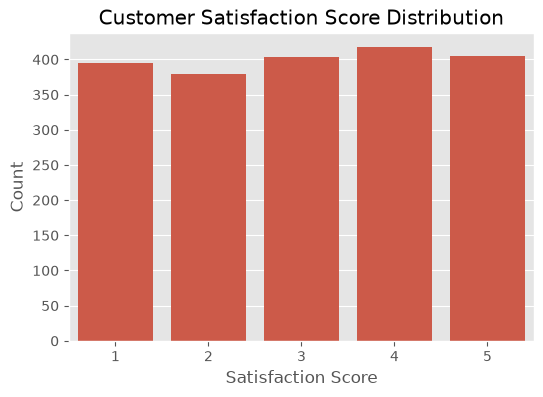

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=clients_df,
    x="satisfaction_score"
)

plt.title("Customer Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")

plt.show()

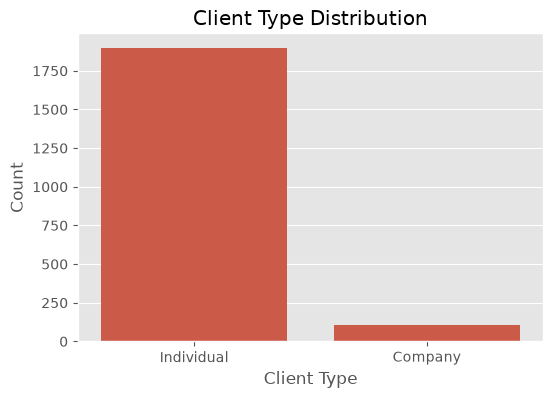

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=clients_df,
    x="client_type"
)

plt.title("Client Type Distribution")
plt.xlabel("Client Type")
plt.ylabel("Count")

plt.show()

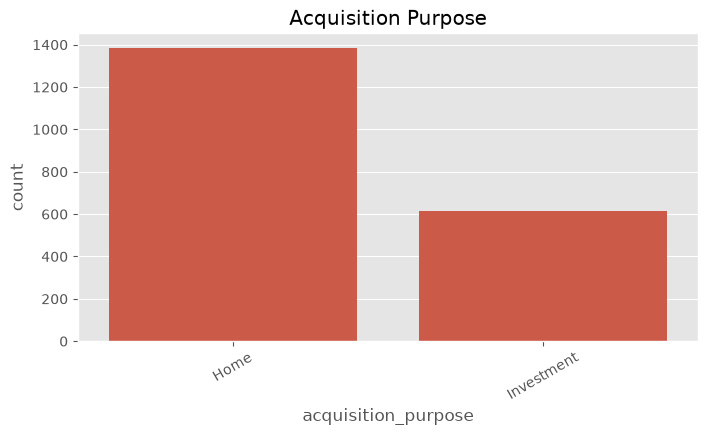

In [22]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=clients_df,
    x="acquisition_purpose"
)

plt.title("Acquisition Purpose")
plt.xticks(rotation=30)
plt.show()

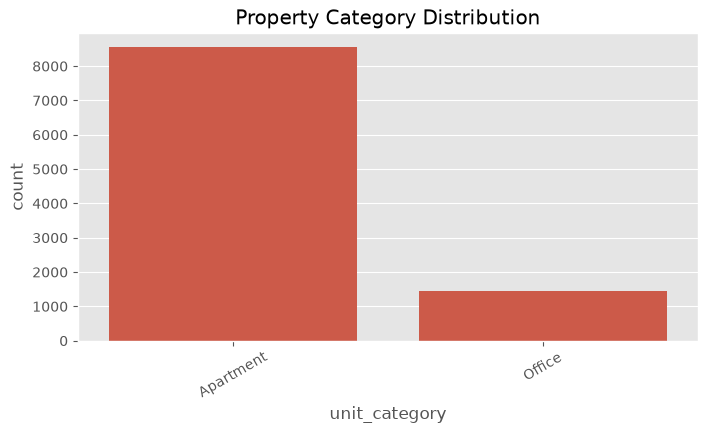

In [23]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=properties_df,
    x="unit_category"
)

plt.title("Property Category Distribution")
plt.xticks(rotation=30)
plt.show()

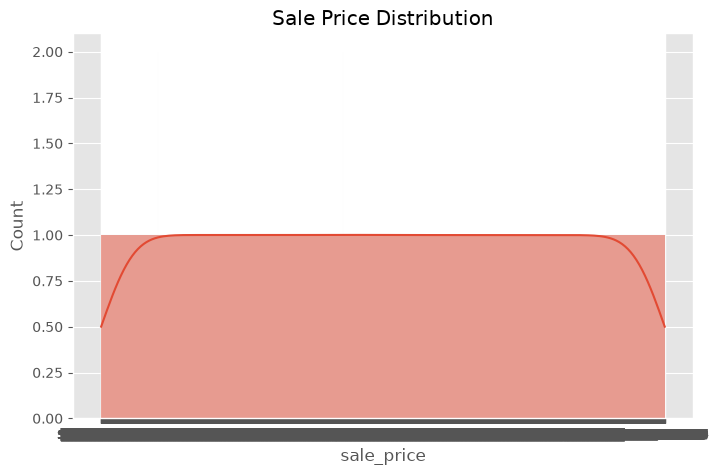

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    properties_df["sale_price"],
    bins=30,
    kde=True
)

plt.title("Sale Price Distribution")
plt.show()

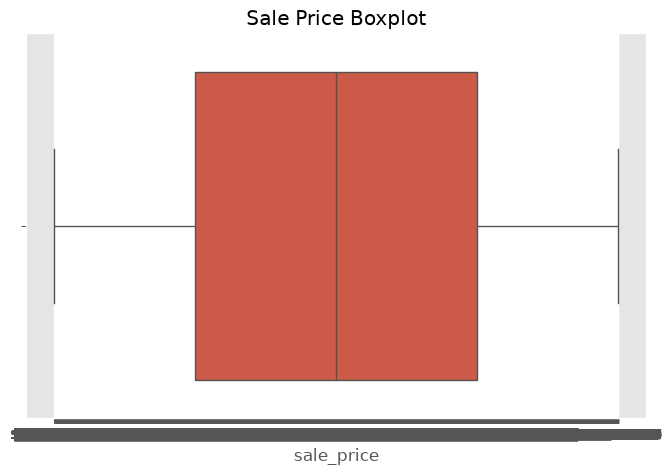

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=properties_df["sale_price"]
)

plt.title("Sale Price Boxplot")

plt.show()

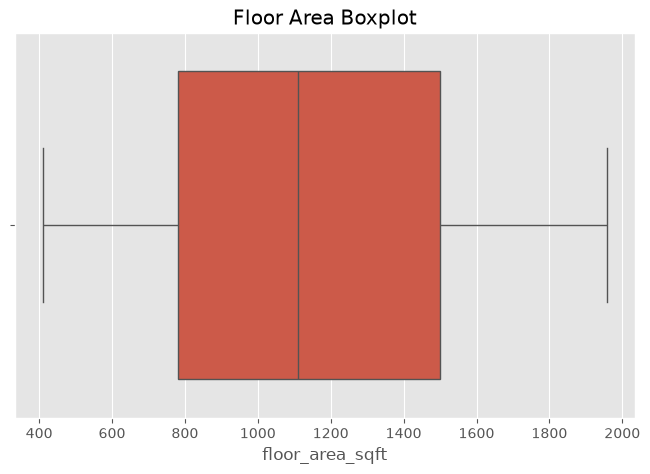

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=properties_df["floor_area_sqft"]
)

plt.title("Floor Area Boxplot")

plt.show()

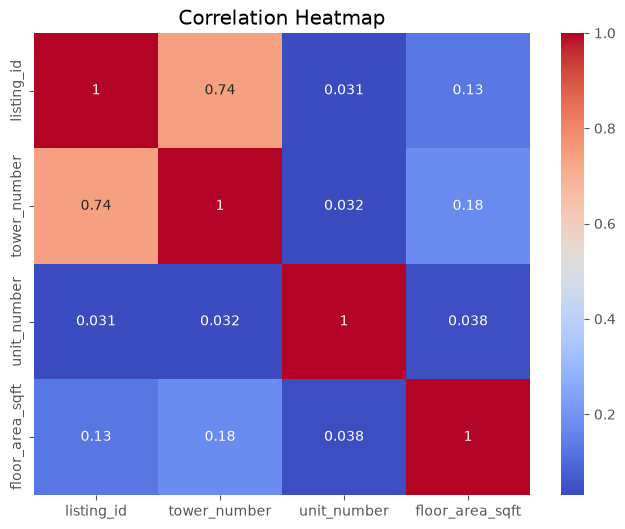

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    properties_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

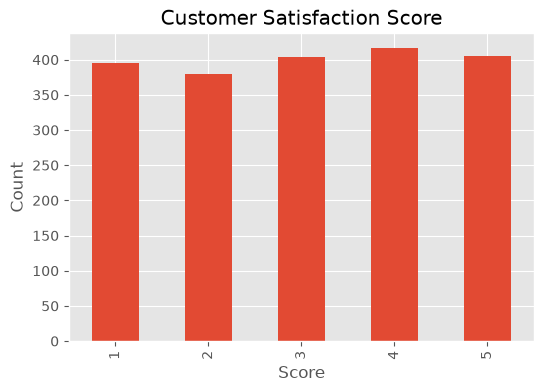

In [29]:
clients_df["satisfaction_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Customer Satisfaction Score")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()